# Упражнение 2.5. Нестационарный 10-рукий стенд: выборочное среднее против постоянного шага

Саттон, Барто, «Обучение с подкреплением».
Полный разбор — в сборнике решений: [глава 2 (PDF)](https://michaeltoschenko.github.io/RL_Sutton_Barto_Solutions/ch02.pdf).


In [3]:
import matplotlib.pyplot as plt
import random
import numpy as np

In [56]:
K = 10
N_TASKS = 500
N_STEPS = 10000
EPS = 0.1
ALPHA = 0.1

In [57]:
def run_solution(k, n_tasks, n_steps, eps, alpha=None):
    reward_res = np.zeros(n_steps)
    prob_res = np.zeros(n_steps)
    for task in range(n_tasks):
        values_true_mu = np.zeros(k)
        values_est = np.zeros(k)
        count = np.zeros(k)
        for step in range(n_steps):
            if np.random.uniform() > eps:
                max_q = np.max(values_est)
                greedy_actions = np.flatnonzero(values_est == max_q)
                action = np.random.choice(greedy_actions)
            else:
                action = np.random.randint(0, k)
            reward = np.random.normal(values_true_mu[action], 1)
            count[action] += 1
            if alpha:
                values_est[action] = values_est[action] + alpha*(reward - values_est[action])
            else:
                values_est[action] = values_est[action] + 1/count[action]*(reward - values_est[action])
            optimal_actions = np.flatnonzero(
                values_true_mu == np.max(values_true_mu)
            )
            prob_res[step] += 1 if action in optimal_actions else 0
            values_true_mu += np.random.normal(0, 0.01, k)
            reward_res[step] += reward
            
    reward_res /= n_tasks
    prob_res /= n_tasks
    return reward_res, prob_res

In [58]:
alpha_reward_res, alpha_prob_res = run_solution(K, N_TASKS, N_STEPS, EPS, ALPHA)
dynamic_reward_res, dynamic_prob_res = run_solution(K, N_TASKS, N_STEPS, EPS)

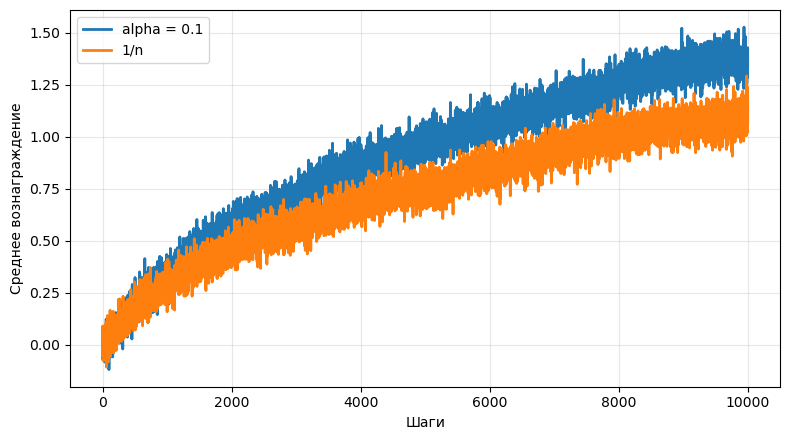

In [59]:
x = np.arange(N_STEPS) 

plt.figure(figsize=(8, 4.5))

plt.plot(x, alpha_reward_res, linewidth=2, label=f'alpha = {ALPHA}')
plt.plot(x, dynamic_reward_res, linewidth=2, label='1/n')

plt.xlabel('Шаги')
plt.ylabel('Среднее вознаграждение')

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

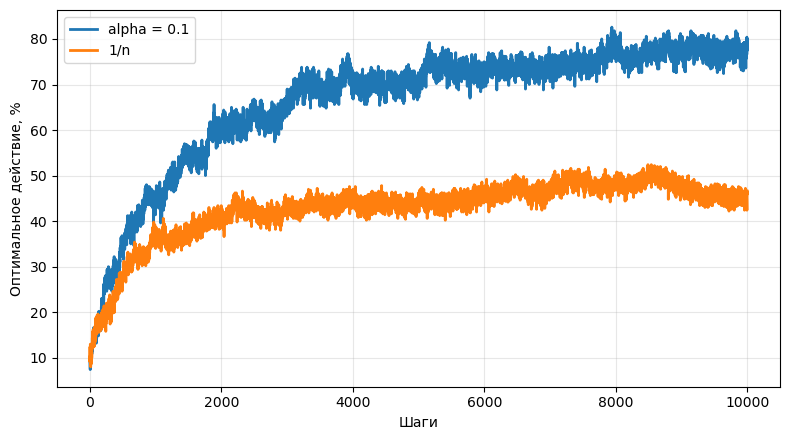

In [60]:
x = np.arange(N_STEPS) 

plt.figure(figsize=(8, 4.5))

plt.plot(x[1:], alpha_prob_res[1:]*100, linewidth=2, label=f'alpha = {ALPHA}')
plt.plot(x[1:], dynamic_prob_res[1:]*100, linewidth=2, label='1/n')

plt.xlabel('Шаги')
plt.ylabel('Оптимальное действие, %')

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()